<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [ ]:
!pip install torch-fidelity -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.4 MB/s eta 0:00:00


In [ ]:
import os
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.models import inception_v3
from scipy.linalg import sqrtm
import torchvision.transforms as tt
import torch.nn.functional as nnF
import torch
import torch.nn as nn
import torch.nn.functional as nnF
import cv2
from tqdm.notebook import tqdm
import torchvision.utils as vutils
from torchvision.utils import save_image, make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import shutil

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

In [ ]:
!gdown '1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x'

Downloading...
From (original): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x
From (redirected): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x&confirm=t&uuid=4bc395fc-7414-4e0c-af2b-4fcd6bc2a676
To: /content/archive.zip
100% 4.28G/4.28G [00:58<00:00, 73.6MB/s]


In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: faces_dataset_small/00055.png  
  inflating: faces_dataset_small/00237.png  
  inflating: faces_dataset_small/00240.png  
  inflating: faces_dataset_small/00241.png  
  inflating: faces_dataset_small/00242.png  
  inflating: faces_dataset_small/00243.png  
  inflating: faces_dataset_small/00244.png  
  inflating: faces_dataset_small/00245.png  
  inflating: faces_dataset_small/00246.png  
  inflating: faces_dataset_small/00247.png  
  inflating: faces_dataset_small/00248.png  
  inflating: faces_dataset_small/00249.png  
  inflating: faces_dataset_small/00253.png  
  inflating: faces_dataset_small/00255.png  
  inflating: faces_dataset_small/00257.png  
  inflating: faces_dataset_small/00258.png  
  inflating: faces_dataset_small/00259.png  
  inflating: faces_dataset_small/00260.png  
  inflating: faces_dataset_small/00261.png  
  inflating: faces_dataset_small/00262.png  
  inflating: faces_dataset_small/00263.png  
  inflating: faces_dataset_small/

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [ ]:
# Я в процессе обучения собираюсь отслеживать метрику FID(Fréchet Inception Distance)-она сравнивает распределения признаков реальных и сгенерированных изображений, извлечённых сетью Inception v3.
#поэтому 500 изображений не будут учавствовать в обучении

def get_dataloaders(image_size, batch_size, val_size=500, root='/content/faces_dataset_small'):

    # Так, тут я подзатупил и пришлось при создании датасета создавать еще и подпапку в папке, иначе у меня ничего не получалось))
    #
    contents = os.listdir(root)
    has_subdirs = any(os.path.isdir(os.path.join(root, item)) for item in contents)

    if not has_subdirs:
        # Делаю подпапку, если все файлы в корне
        new_subdir = os.path.join(root, 'all_faces')
        os.makedirs(new_subdir, exist_ok=True)

        # Переносим все файлы изображений в новую  подпапку
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        for item in contents:
            item_path = os.path.join(root, item)
            if os.path.isfile(item_path) and os.path.splitext(item)[1].lower() in image_extensions:
                shutil.move(item_path, os.path.join(new_subdir, item))
        print(f'Изображения перенесены в {new_subdir}')

    # Небольшие трансформации
    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # Загрузка датасета
    full_dataset = ImageFolder(root=root, transform=transform)

    # Разделение на тренировочную и валидационную выборки
    train_len = len(full_dataset) - val_size
    val_len = val_size
    train_dataset, val_dataset = random_split(
        full_dataset, [train_len, val_len],
        generator=torch.Generator().manual_seed(42)  # для воспроизводимости использую 42
    )

    # Даталоудер для обучения
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        drop_last=True
    )

    # А этот для метрики
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        drop_last=False
    )

    return train_loader, val_loader

In [ ]:
train_loader, val_loader = get_dataloaders(image_size=128, batch_size=64)

Изображения перенесены в /content/faces_dataset_small/all_faces


## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_size=128, image_size=128):
        super().__init__()
        self.init_size = image_size // 16
        self.fc = nn.Linear(latent_size, 512 * self.init_size * self.init_size)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),   nn.Tanh()
        )
    def forward(self, z):
        out = self.fc(z.view(z.size(0), -1))
        out = out.view(out.size(0), 512, self.init_size, self.init_size)
        return self.main(out)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, image_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

In [ ]:
#Сделал инициализацию весов для более стабильного обучения
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [ ]:
#Вообще в пайторче есть какая-то встроенная штука которая позволяет отслеживать FID, но у меня она почему-то не работала(хз почему). Посовещавшись с нейронкой
#она предложила мне реализовать ее вручную. Этот блок и блок ниже написаны нейронкой, здесь собственно и отслеживается метрика.

def get_inception_features(loader_or_list, device, is_real=True, generator=None, latent_size=100):
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.eval()

    features = []
    with torch.no_grad():
        if is_real:
            iterator = loader_or_list
        else:
            def fake_generator():
                for real_imgs, _ in loader_or_list:
                    batch_size = real_imgs.size(0)
                    noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
                    fake = generator(noise)
                    if fake.min() < 0:
                        fake = (fake + 1) / 2
                    yield fake
            iterator = fake_generator()

        for imgs in iterator:
            if not is_real:
                imgs_batch = imgs
            else:
                imgs_batch, _ = imgs
            imgs_batch = imgs_batch.to(device)
            if imgs_batch.min() < 0:
                imgs_batch = (imgs_batch + 1) / 2
            if imgs_batch.shape[2] != 299:
                imgs_batch = nnF.interpolate(imgs_batch, size=(299, 299), mode='bilinear', align_corners=False)
            # Прямой проход до avgpool
            x = inception.Conv2d_1a_3x3(imgs_batch)
            x = inception.Conv2d_2a_3x3(x)
            x = inception.Conv2d_2b_3x3(x)
            x = inception.maxpool1(x)
            x = inception.Conv2d_3b_1x1(x)
            x = inception.Conv2d_4a_3x3(x)
            x = inception.maxpool2(x)
            x = inception.Mixed_5b(x)
            x = inception.Mixed_5c(x)
            x = inception.Mixed_5d(x)
            x = inception.Mixed_6a(x)
            x = inception.Mixed_6b(x)
            x = inception.Mixed_6c(x)
            x = inception.Mixed_6d(x)
            x = inception.Mixed_6e(x)
            x = inception.Mixed_7a(x)
            x = inception.Mixed_7b(x)
            x = inception.Mixed_7c(x)
            x = inception.avgpool(x)
            feat = x.squeeze(-1).squeeze(-1).cpu().numpy()
            features.append(feat)
    return np.concatenate(features, axis=0)

In [ ]:
def calculate_fid(real_features, fake_features, eps=1e-6):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    sigma1 += np.eye(sigma1.shape[0]) * eps
    sigma2 += np.eye(sigma2.shape[0]) * eps
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = np.real(covmean)
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

In [ ]:
def train_gan(train_loader, val_loader, generator, discriminator, epochs=100, lr=0.0002, latent_size=128, device='cuda'):
    g_opt = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    loss_fn = nn.BCELoss()

    fixed_noise = torch.randn(64, latent_size, 1, 1, device=device)
    history = {'d_loss':[],'g_loss':[],'d_real':[],'d_fake':[],'fid':[],'fid_epochs':[]}

    # Предварительно считаем real features для FID
    from torchvision.models import inception_v3

    real_features = get_inception_features(val_loader, device, is_real=True)

    for epoch in range(1, epochs+1):
        d_loss_epoch, g_loss_epoch, d_real_acc, d_fake_acc = [], [], [], []
        for real, _ in train_loader:
            bs = real.size(0)
            real = real.to(device)
            # Тренировка дискриминатора
            d_opt.zero_grad()
            real_pred = discriminator(real).view(-1)
            real_loss = loss_fn(real_pred, torch.full((bs,), 0.9, device=device))
            acc_real = (real_pred > 0.5).float().mean().item()

            z = torch.randn(bs, latent_size, 1, 1, device=device)
            fake = generator(z).detach()
            fake_pred = discriminator(fake).view(-1)
            fake_loss = loss_fn(fake_pred, torch.full((bs,), 0.1, device=device))
            acc_fake = (fake_pred <= 0.5).float().mean().item()

            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_opt.step()

            # Тренировка генератора
            g_opt.zero_grad()
            z = torch.randn(bs, latent_size, 1, 1, device=device)
            fake = generator(z)
            fake_pred = discriminator(fake).view(-1)
            g_loss = loss_fn(fake_pred, torch.full((bs,), 0.9, device=device))
            g_loss.backward()
            g_opt.step()

            d_loss_epoch.append(d_loss.item())
            g_loss_epoch.append(g_loss.item())
            d_real_acc.append(acc_real)
            d_fake_acc.append(acc_fake)

        # Логи
        avg_d = sum(d_loss_epoch)/len(d_loss_epoch)
        avg_g = sum(g_loss_epoch)/len(g_loss_epoch)
        avg_d_real = sum(d_real_acc)/len(d_real_acc)
        avg_d_fake = sum(d_fake_acc)/len(d_fake_acc)
        history['d_loss'].append(avg_d); history['g_loss'].append(avg_g)
        history['d_real'].append(avg_d_real); history['d_fake'].append(avg_d_fake)
        print(f"Epoch {epoch}: D loss {avg_d:.3f} G loss {avg_g:.3f} D real acc {avg_d_real:.3f} D fake acc {avg_d_fake:.3f}")

        # FID каждые 5 эпох
        if epoch % 5 == 0 or epoch == 1:
            generator.eval()
            fake_features = get_inception_features(val_loader, device, is_real=False, generator=generator, latent_size=latent_size)
            fid = calculate_fid(real_features, fake_features)
            history['fid'].append(fid); history['fid_epochs'].append(epoch)
            print(f"  FID = {fid:.2f}")
            # Сохраняем лучшую модель
            if fid == min(history['fid']):
                torch.save(generator.state_dict(), "best_generator.pth")
                print("  Лучшая модель сохранена.")
            generator.train()

        # Изображения каждые несколько эпох
        if epoch % 5 == 0:
            generator.eval()
            with torch.no_grad():
                fake_grid = generator(fixed_noise)
                fake_grid = (fake_grid + 1) / 2  # к [0,1]
                grid = vutils.make_grid(fake_grid, nrow=8, padding=2)
                vutils.save_image(grid, f"epoch_{epoch}.png")
                plt.imshow(grid.cpu().permute(1,2,0)); plt.axis('off'); plt.show()
            generator.train()
    return generator, history

In [ ]:
device = 'cuda'

generator = Generator(latent_size=128, image_size=128).apply(weights_init).to(device)
discriminator = Discriminator(image_size=128).apply(weights_init).to(device)


'\noptimizer = {\n    "discriminator": torch.optim.Adam(model[\'discriminator\'].parameters(), betas=(0.5, 0.999)),\n    "generator": torch.optim.Adam(model[\'generator\'].parameters(), betas=(0.5, 0.999))\n}\n'

In [ ]:
generator, history = train_gan(
    train_loader, val_loader, generator, discriminator,
    epochs=100, lr=0.0002, latent_size=128, device='cuda'
)

Output hidden; open in https://colab.research.google.com to view.

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['d_loss']) + 1)

    plt.figure(figsize=(14, 10))

    # Лоссы
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['d_loss'], label='D loss', color='red')
    plt.plot(epochs, history['g_loss'], label='G loss', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator and Discriminator Loss')
    plt.legend()
    plt.grid(True)

    # Точности дискриминатора (ключи 'd_real' и 'd_fake')
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['d_real'], label='D accuracy on real', color='green')
    plt.plot(epochs, history['d_fake'], label='D accuracy on fake', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Discriminator Accuracy')
    plt.legend()
    plt.grid(True)

    # FID
    if 'fid' in history and 'fid_epochs' in history:
        plt.subplot(2, 2, 3)
        plt.plot(history['fid_epochs'], history['fid'], marker='o', linestyle='-', color='purple')
        plt.xlabel('Epoch')
        plt.ylabel('FID')
        plt.title('FID score over training')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

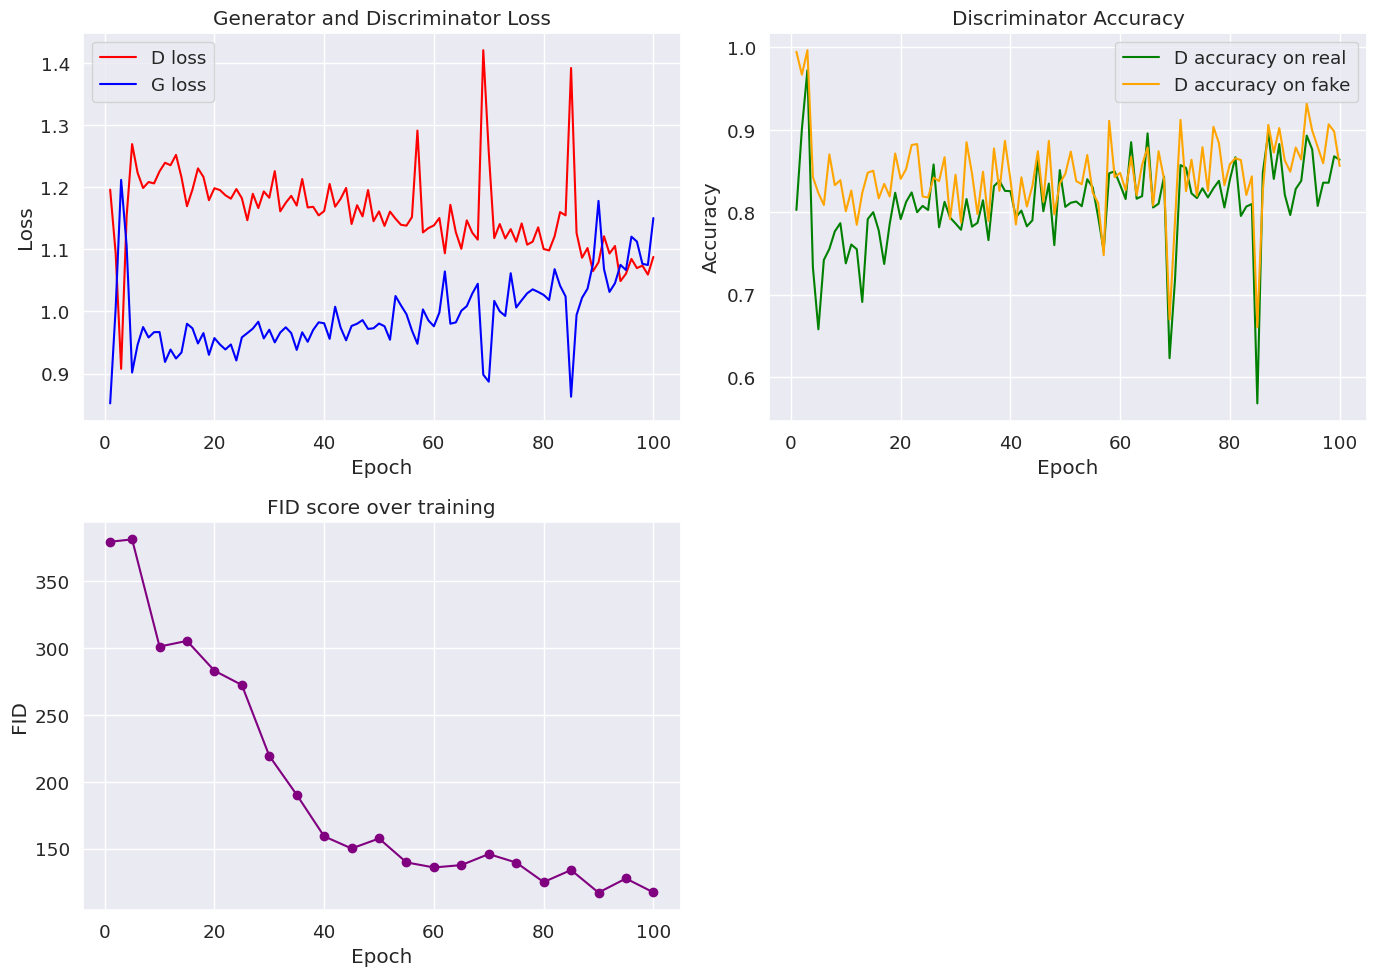

In [ ]:

plot_training_history(history)

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [ ]:
def show_images(generated, nrow=8, figsize=(12, 12), title=None):

    # Если значения в диапазоне [-1, 1],
    # приводим к [0, 1] для отображения
    if generated.min() < 0:
        generated = (generated + 1) / 2

    # Создаём сетку изображений
    grid = vutils.make_grid(generated, nrow=nrow, padding=2, normalize=False)

    # Переводим в numpy для matplotlib:
    np_grid = grid.cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=figsize)
    plt.imshow(np_grid)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

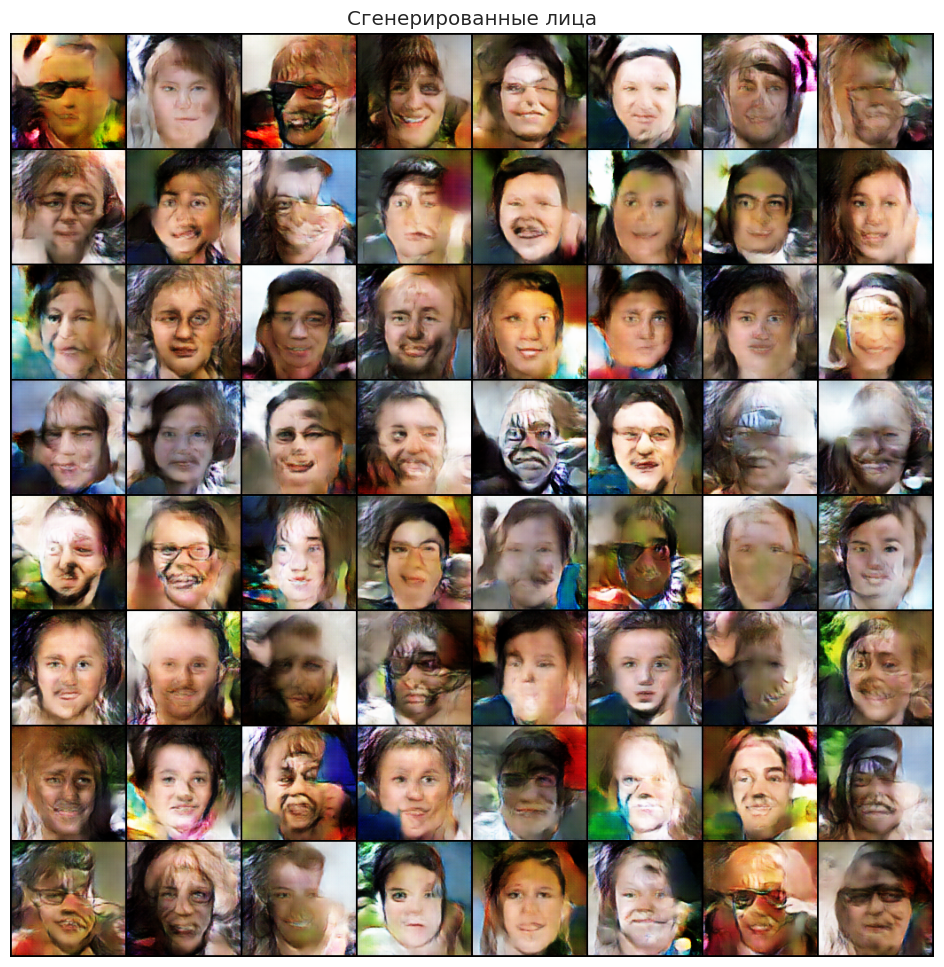

In [ ]:
# Генерация 64 изображений с фиксированным шумом
latent_size = 128
noise = torch.randn(64, latent_size, 1, 1, device=device)
with torch.no_grad():
    fake_images = generator(noise)
    show_images(fake_images, nrow=8, title='Сгенерированные лица')

Как вам качество получившихся изображений?

Ну основные элементы лиц  генерируются:рот, нос, глаза на месте. Качество конечно такое себе, но если подобрать получше гиперпаратры, сделать более гибкое обучение и добавить трансформация, то можно добится результата получше.

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut

def compute_1nn_loo_accuracy(real_loader, generator, device, latent_size, max_samples=None):

    generator.eval()

    # Собираем все реальные изображения
    real_images = []
    with torch.no_grad():
        for imgs, _ in real_loader:
            real_images.append(imgs.cpu())
    real_images = torch.cat(real_images, dim=0)

    if max_samples is not None:
        real_images = real_images[:max_samples]

    n_real = real_images.size(0)
    print(f"Количество реальных изображений: {n_real}")

    # Генерируем столько же фейковых
    fake_images = []
    batch_size = real_loader.batch_size
    with torch.no_grad():
        for i in range(0, n_real, batch_size):
            current_bs = min(batch_size, n_real - i)
            noise = torch.randn(current_bs, latent_size, 1, 1, device=device)
            fake = generator(noise).cpu()
            fake_images.append(fake)
    fake_images = torch.cat(fake_images, dim=0)[:n_real]  # точно n_real штук

    # Преобразуем в плоские векторы
    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(n_real, -1).numpy()

    # Формируем данные и метки
    X = np.concatenate([real_flat, fake_flat], axis=0)  # (2 * n_real, D)
    y = np.concatenate([np.ones(n_real), np.zeros(n_real)])  # реальные = 1, фейк = 0

    # Leave-One-Out кросс-валидация с 1-NN
    loo = LeaveOneOut()
    knn = KNeighborsClassifier(n_neighbors=1)
    correct = 0
    total = 0

    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)
        if pred[0] == y_test[0]:
            correct += 1
        total += 1

    accuracy = correct / total
    print(f"1-NN LOO Accuracy: {accuracy:.4f}")
    return accuracy

In [ ]:
# Предположим, train_loader содержит реальные изображения, generator – обученная модель
acc = compute_1nn_loo_accuracy(train_loader, generator, device='cuda', latent_size=128, max_samples=500)
print(f"1-NN LOO accuracy: {acc:.3f}")

Количество реальных изображений: 500
1-NN LOO Accuracy: 0.7860
1-NN LOO accuracy: 0.786


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

Итак, судя по моим результатам примерно в 78% случаев модель можешь отличить сгенерированное изображение от реального. Для моей модели результат в принципе ожидаемый. В идеале значение должно быть около 0.5, то есть модель не может убедительно отличить сгенерированное изображение от реально в половине случаев.

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_real_fake(real_loader, generator, device, latent_size, max_samples=1000,
                        perplexity=30, random_state=42):

    generator.eval()

    # Собираем реальные изображения
    real_images = []
    with torch.no_grad():
        for imgs, _ in real_loader:
            real_images.append(imgs.cpu())
    real_images = torch.cat(real_images, dim=0)
    if max_samples and real_images.size(0) > max_samples:
        # случайно выбираем max_samples
        idx = np.random.choice(real_images.size(0), max_samples, replace=False)
        real_images = real_images[idx]
    n_samples = real_images.size(0)
    print(f"Используем {n_samples} реальных изображений")

    # Генерируем столько же фейковых
    fake_images = []
    batch_size = real_loader.batch_size
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            current_bs = min(batch_size, n_samples - i)
            noise = torch.randn(current_bs, latent_size, 1, 1, device=device)
            fake = generator(noise).cpu()
            fake_images.append(fake)
    fake_images = torch.cat(fake_images, dim=0)[:n_samples]

    # Преобразуем в плоские векторы
    real_flat = real_images.view(n_samples, -1).numpy()
    fake_flat = fake_images.view(n_samples, -1).numpy()

    # Объединяем и уменьшаем размерность t-SNE
    X = np.concatenate([real_flat, fake_flat], axis=0)
    y = np.array([1] * n_samples + [0] * n_samples)  # 1 - реальные, 0 - фейковые

    print("Запуск t-SNE (может занять некоторое время)...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    X_tsne = tsne.fit_transform(X)

    # Рисуем
    plt.figure(figsize=(10, 8))
    plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], c='blue', label='Real', alpha=0.6, s=10)
    plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], c='red', label='Fake', alpha=0.6, s=10)
    plt.legend()
    plt.title('t-SNE visualization of real vs. generated images')
    plt.axis('off')
    plt.show()

Используем 1000 реальных изображений
Запуск t-SNE (может занять некоторое время)...


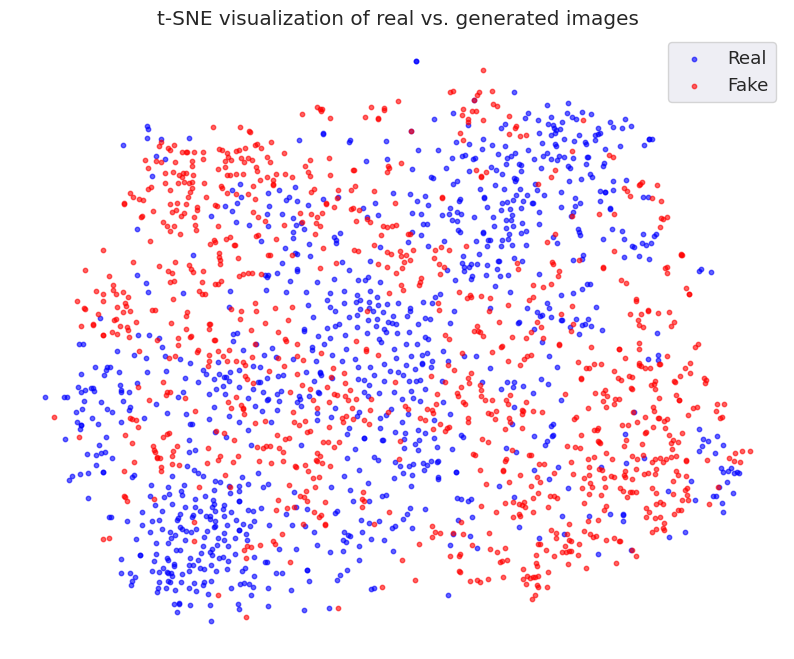

In [ ]:
plot_tsne_real_fake(train_loader, generator, device='cuda', latent_size=128, max_samples=1000)

Прокомментируйте получившийся результат:

В иделе все точки должны быть равномерно перемешаны, без образования четких кучек - это  бы  означало, что генератор хорошо воспроизводит изображения. Но в  моем случае есть определенная кластеризация групп, а значит сгенерированные изображения отличимы от реальных, что соответсвтвует моим прошлым результатам.